In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM
from multicam.qt import qt
from scipy.stats import spearmanr

from astropy.table import Table

TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [13]:
def generate_randoms(Lbox, number):
    """Generate randoms to be used for tpcf_jackknife
    Args:
        Lbox: size of TNG simulation box
        number: desired number of randoms, i.e. 10,000
    Return:
        Nran: xyz formatted array of uniform random variables
    """
    Xran = np.random.uniform(0, Lbox, number)
    Yran = np.random.uniform(0, Lbox, number)
    Zran = np.random.uniform(0, Lbox, number)
    Nran = return_xyz_formatted_array(Xran, Yran, Zran)
    return Nran


In [14]:
# -----------------------------
# Load data
# -----------------------------
# TODO: apply subhalo flag
hydro_raw = Table.read("../../data/hydro_final.ecsv")
len(hydro_raw)

101431

In [15]:
# Stellar mass cut
# NOTE: this cut can potentially bias the results so we avoid it
# although Ismael and Phil checked that it does not really matter.
# hydro_full = hydro_full[
#     hydro_full['StellarMass'] >= (1.4e8 * TNG_H)
# ]

# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [16]:
# cut based on mpeak
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = (log_mpeak > 11) & (log_mpeak < 12)
hydro_full = hydro_raw[mpeak_cut_mask]
len(hydro_full)

11316

In [17]:
# -----------------------------
# Define SHAM baseline
# -----------------------------
log10_mpeak = np.log10(hydro_full["mpeak"].data)
log10_stellar_mass = np.log10(hydro_full["stellar_mass"].data)

print(len(log10_mpeak), len(log10_stellar_mass))
assert len(log10_mpeak) == len(log10_stellar_mass)

# SHAM mean relation (NO scatter), also defines SHMR
logmstar_sham = qt(log10_mpeak, log10_stellar_mass)

11316 11316


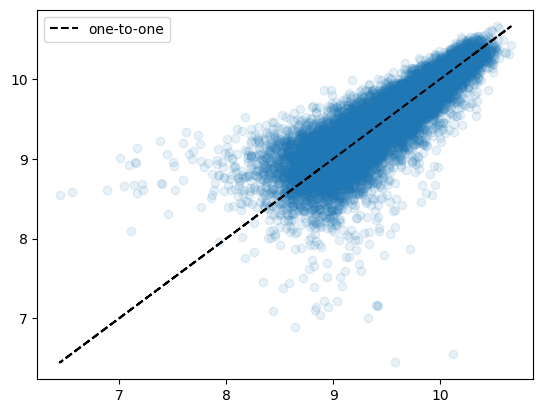

In [18]:
# what does the SHMR look like
plt.scatter(logmstar_sham, log10_stellar_mass, alpha=0.1)
plt.plot(log10_stellar_mass, log10_stellar_mass, ls="--", c="k", label="one-to-one")
plt.legend()

In [19]:
star_mask = (log10_stellar_mass > 9.5) & (log10_stellar_mass < 10.2)
hydro_mstar_cut = hydro_full[star_mask]

sham_mask = (logmstar_sham > 9.5) & (logmstar_sham < 10.2)
hydro_mstar_pred = hydro_full[sham_mask]


len(hydro_mstar_cut), len(hydro_mstar_pred)


(4002, 4002)

In [20]:
# CAM prediction for color
# possibly resample
# _color = np.random.choice(hydro_mstar_cut['color'].data, size=len(hydro_mstar_cut), replace=True)
_color = hydro_mstar_cut["color"]
color_cam_pred = qt(hydro_mstar_pred["z12"].data, _color)
color_cam_pred.shape

(4002,)

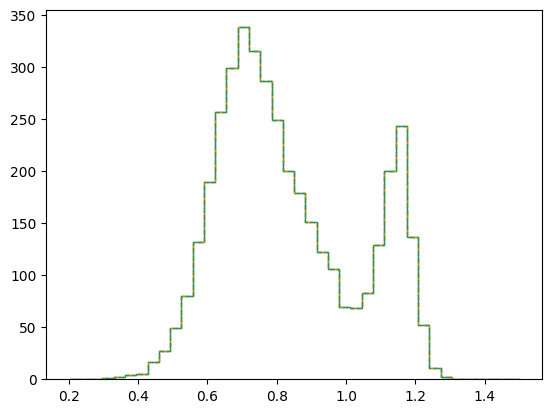

In [21]:
bins = np.linspace(0.2, 1.5, 41)

plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step")
plt.hist(color_cam_pred, bins=bins, histtype="step", linestyle="-.")
plt.hist(_color, bins=bins, histtype="step", linestyle="--");
# shoudl be exactly the same

In [22]:
spearmanr(hydro_mstar_cut["color"], color_cam_pred), spearmanr(_color, color_cam_pred)

(SignificanceResult(statistic=np.float64(0.2686133315231124), pvalue=np.float64(4.197518076216721e-67)),
 SignificanceResult(statistic=np.float64(0.2686133315231124), pvalue=np.float64(4.197518076216721e-67)))

## Clustering (CAM)

In [30]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)
randoms.shape

(50000, 3)

In [31]:
red_pred = hydro_mstar_pred[color_cam_pred > COLOR_CUT]
blue_pred = hydro_mstar_pred[color_cam_pred <= COLOR_CUT]

true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


In [32]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [33]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


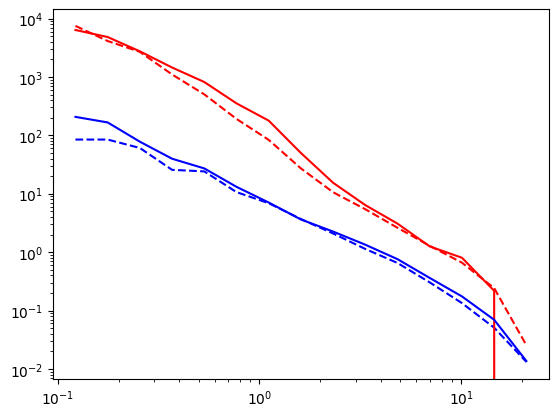

In [34]:
plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--")

plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b")

(0.2, 2.0)

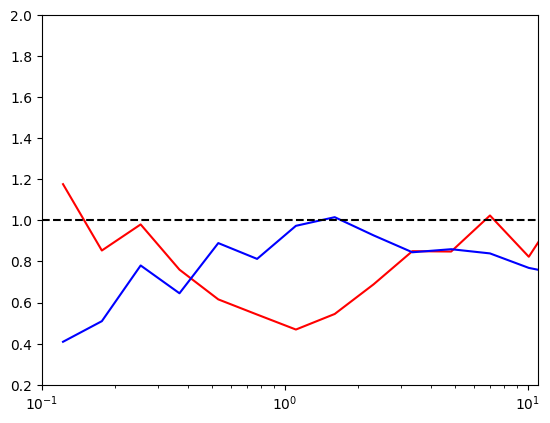

In [35]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-")

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output

## Repeat with multicam a_{1/2} only

In [23]:
_color = hydro_mstar_cut["color"]

x = hydro_mstar_pred["a12"].data.reshape(-1, 1)
y = _color.reshape(-1, 1)

model = MultiCAM(1, 1)
model.fit(x, y)
multicam_color_pred = model.predict(x)[:, 0]
multicam_color_pred.shape

(4002,)

In [24]:
multicam_red_pred = hydro_mstar_pred[multicam_color_pred > COLOR_CUT]
multicam_blue_pred = hydro_mstar_pred[multicam_color_pred <= COLOR_CUT]

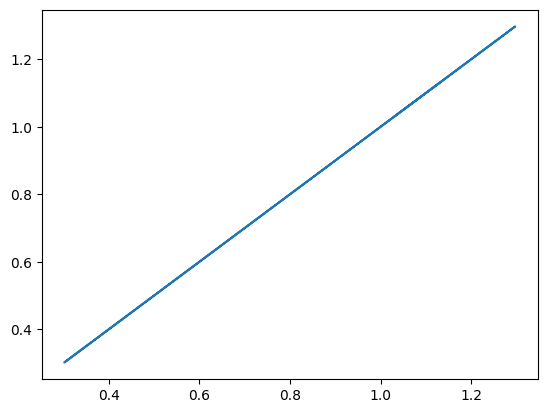

In [25]:
plt.plot(multicam_color_pred, color_cam_pred)

In [39]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


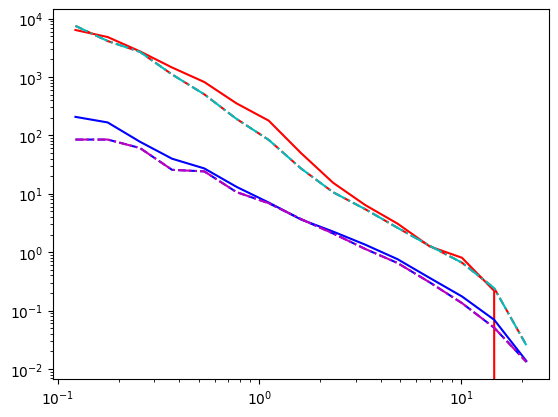

In [44]:
plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--")

plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b")

plt.loglog(rbin_centers, xi_red_multicam, c="c", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="m", ls="-.")

In [45]:
# NOTE: exactly the same after correctly interpolating a12